Test AUC: 0.9940476190476191

Confusion Matrix:
[[71  1]
 [ 5 37]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



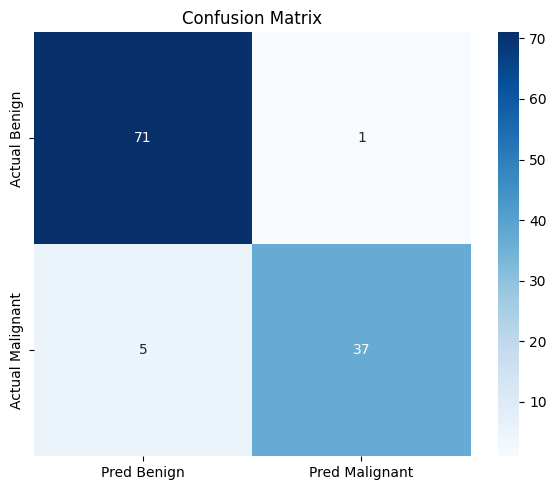

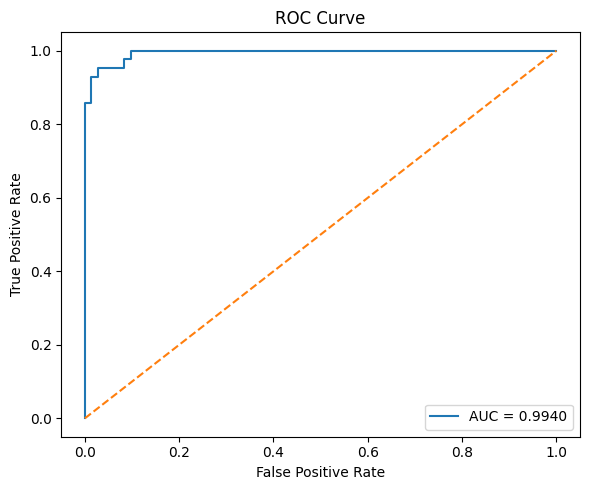

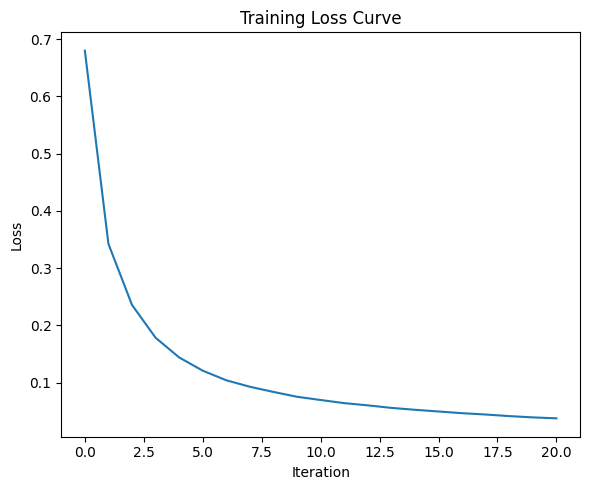

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

#read data
file_path = r"C:\Users\Colin Briggs\Downloads\data.csv"
df = pd.read_csv(file_path)

#drop useless columns
if "Unnamed: 32" in df.columns:
    df = df.drop(columns=["Unnamed: 32"])

if "id" in df.columns:
    df = df.drop(columns=["id"])

#encode target
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

#split predictors and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#build neural network
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=16,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=15,
    random_state=42
)

#fit model
model.fit(X_train_scaled, y_train)

#predicted probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#predicted classes
y_pred = model.predict(X_test_scaled)

#auc
auc = roc_auc_score(y_test, y_prob)
print("Test AUC:", auc)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

#classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

#plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["Actual Benign", "Actual Malignant"]
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#plot roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()